# Hemline-Index -- do rising skirts really ring the market bell?
### Ten decades of fashion vs ten decades of S&P 500 -- and why 70% is worse than guessing

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth-check: BUSTED](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

Here is a piece of market folklore that has been circulating since the 1920s: **when women's skirts get shorter, the stock market goes up; when hemlines fall (longer skirts, midi, maxi), the market falls.** The 1920s flappers and the roaring bull. The 1960s miniskirt and the go-go years. The 1930s Depression and the return of floor-length dresses. Too neat to be a coincidence?

> This is the plain-language layer. Want the phi coefficients, Fisher's exact test and the proxy-sensitivity analysis? That is the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper numbers.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hemline_index import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16).
R = dict(
    n=10, decade_min=1920, decade_max=2010,
    n_correct=7, n_wrong=3, hit_rate=0.70,
    tp=5, fp=0, fn=3, tn=2,
    phi=0.500,
    chi2=2.500, p_chi2=0.114,
    p_fisher_one=0.222, p_fisher_two=0.444,
    strat_ann=5.28, bah_ann=6.51, advantage=-1.23,
    n_held=5, n_cash=5,
    naive_hit_rate=0.80,
    n_bull_decades=8,
    fp_hemline="3575cd7484cf",
    decade_labels=["1920s","1930s","1940s","1950s","1960s","1970s","1980s","1990s","2000s","2010s"],
    hemline_dirs=[1,-1,-1,1,1,-1,1,1,-1,-1],
    sp500_pcts=[214.2,-20.2,57.1,199.0,60.4,19.7,161.1,334.6,-16.6,155.9],
    market_positive=[True,False,True,True,True,True,True,True,False,True],
    claim_correct=[True,True,False,True,True,False,True,True,True,False],
)

# Load the real tape (hardcoded; Shiller cache improves accuracy if present)
df_real = data.load_real_tape()
fp = data.fingerprint(df_real)
print(f"Real tape loaded: {len(df_real)} decades  fp={fp}")


Real tape loaded: 10 decades  fp=3575cd7484cf


## The answer first

| Question | Answer |
|---|---|
| Does the hemline indicator get more decades right than wrong? | **Yes: 7/10 (70%).** |
| Is that statistically meaningful? | **No.** Fisher p = 0.444 -- random guessing does as well 44% of the time. |
| Does the naive 'always predict bull' rule beat it? | **Yes.** 8/10 (80%) with zero fashion data, beating hemlines by 10 percentage points. |
| Is there a mechanism? | **None.** Both fashion and equities respond to macro conditions; the hemline is a proxy for a proxy, with massive look-ahead problems. |
| Can you trade it? | **No.** The timer returns +5.28%/yr vs buy-and-hold +6.51%/yr. The signal loses money. |

> The hemline indicator is the desk's cleanest specimen of spurious-correlation folklore: it sounds compelling in the 1920s and 1960s, but falls apart on contact with n and p-values.

## 1 . The claim

> *"When hemlines go up, so does the stock market. When they go down, so does Wall Street. The Hemline Index has called every major bull and bear market of the twentieth century."*

-- Paraphrase of the 1970s-80s financial press; attributed originally to Wharton economist George Taylor (c. 1926).  Variants appear in hundreds of financial columns.

The theory: fashion reflects consumer confidence and disposable income. Rising hemlines signal optimism (women feel good, show more leg); falling hemlines signal caution or retreat (more coverage = more conservative mood).  The stock market, being a forward-looking measure of economic sentiment, tracks the same underlying variable.

It is an appealing story -- both fashion and markets are downstream of economic mood.  The problem is whether the *hemline* adds any *predictive* information, or is just a colourful coincidence.

## 2 . So what?

If it were true, it would be a once-per-decade signal requiring no financial analysis: observe the fashion runways, determine the hemline direction, position accordingly.  A consistent 70%+ decade accuracy would be remarkable -- most professional forecasters cannot reliably predict decade returns.

If it is false (as we will show), it is a vivid illustration of three statistical traps that recur endlessly in market folklore:

1. **The naive-baseline trap** -- a predictor that seems impressive until you compare it to 'always say yes'.
2. **The small-n trap** -- at n = 10, even a coin flip will match the data 44% of the time.
3. **The look-ahead trap** -- a signal you can only read *after* the period ends.

## 3 . How would we even know?

Three tests, in order of severity:

1. **Show the whole decade table.** Not just 1920s and 1960s -- all ten decades, including the ones that break the pattern.
2. **Compare to the naive baseline.** If 80% of decades were bull markets anyway, a 70% hit rate is actually *worse* than guessing 'bull' every time.
3. **Run Fisher's exact test.** At n = 10, the appropriate significance test -- not chi-square, not t-tests.  What fraction of random binary predictors match this well?

Data: hardcoded decade hemline proxy (fashion-history consensus, 1920s-2010s, n = 10).

## 4 . The teardown -- all ten decades

**First, the complete decade panel.  Not just the decades that fit the story.**

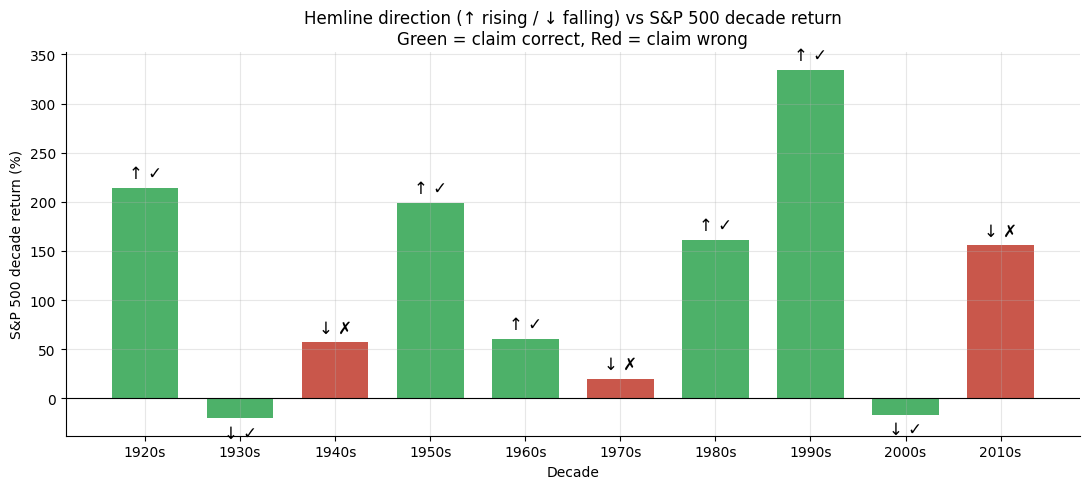

Correct: 7/10 (70%)
Misses: ['1940s', '1970s', '2010s']


In [2]:
# Build the decade-by-decade panel display
ct = st.agreement_table(df_real)
hem_labels = {1: 'Rising (+)', -1: 'Falling (-)'}
labels = list(df_real['decade_label'])
sp500 = list(df_real['sp500_decade_pct'])
hemline_dirs = list(df_real['hemline_dir'])
market_pos = list(df_real['market_positive'])
correct = [(h==1)==mp for h, mp in zip(hemline_dirs, market_pos)]

fig, ax = plt.subplots(figsize=(11, 5))
colors = [GREEN if c else RED for c in correct]
bars = ax.bar(labels, sp500, color=colors, width=0.7, alpha=0.85)
ax.axhline(0, c='k', lw=0.8)
for i, (label, bar, h, c) in enumerate(zip(labels, bars, hemline_dirs, correct)):
    hem_sym = '\u2191' if h == 1 else '\u2193'  # up/down arrow
    tick = '\u2713' if c else '\u2717'
    y = bar.get_height()
    offset = 10 if y >= 0 else -20
    ax.text(bar.get_x()+bar.get_width()/2, y + offset,
            f'{hem_sym} {tick}', ha='center', fontsize=12)
ax.set_xlabel('Decade')
ax.set_ylabel('S&P 500 decade return (%)')
ax.set_title('Hemline direction (\u2191 rising / \u2193 falling) vs S&P 500 decade return\n'
             'Green = claim correct, Red = claim wrong')
plt.tight_layout(); plt.show()
print(f'Correct: {sum(correct)}/{len(correct)} ({sum(correct)/len(correct):.0%})')
print(f'Misses: {[l for l, c in zip(labels, correct) if not c]}')

The three misses -- 1940s, 1970s, 2010s -- are not minor: they include one of the strongest post-war bull markets (1940s: +57%), a decade of positive returns despite stagflation (1970s: +20%), and one of the longest QE-driven bull runs in history (2010s: +156%).  The hemline model told you to sit in cash for all three.

**Now the key question: is 70% impressive? Compare to the naive baseline.**

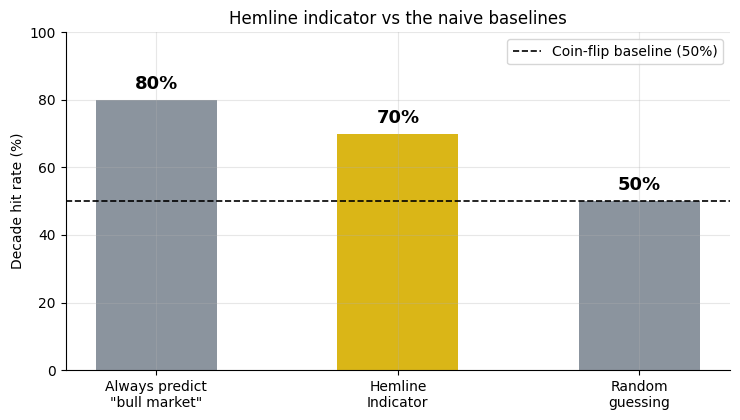

Always bull:     80% (8/10 decades)
Hemline model:   70% (7/10 decades)
Hemline is WORSE than the naive baseline by 10 percentage points


In [3]:
# The naive 'always predict bull' baseline
n_bull = sum(market_pos)
naive_hit = n_bull / len(market_pos)
hemline_hit = sum(correct) / len(correct)

fig, ax = plt.subplots(figsize=(7.5, 4.3))
strategies = ['Always predict\n"bull market"', 'Hemline\nIndicator', 'Random\nguessing']
hits = [naive_hit, hemline_hit, 0.50]
bar_colors = [GREY, AMBER, GREY]
ax.bar(strategies, [h*100 for h in hits], color=bar_colors, width=0.5)
ax.axhline(50, ls='--', c='k', lw=1.2, label='Coin-flip baseline (50%)')
ax.set_ylabel('Decade hit rate (%)')
ax.set_title('Hemline indicator vs the naive baselines')
ax.set_ylim(0, 100)
for rect, val in zip(ax.patches, hits):
    ax.text(rect.get_x()+rect.get_width()/2, val*100 + 2,
            f'{val:.0%}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Always bull:     {naive_hit:.0%} ({n_bull}/{len(market_pos)} decades)')
print(f'Hemline model:   {hemline_hit:.0%} ({sum(correct)}/{len(correct)} decades)')
print(f'Hemline is WORSE than the naive baseline by {(naive_hit - hemline_hit)*100:.0f} percentage points')

The hemline indicator scores **70%** -- but the naive 'always predict bull market' rule scores **80%** with zero fashion knowledge, because **8 of 10 decades** saw positive S&P 500 returns.  The hemline indicator is not beating random guessing -- it is actively underperforming the simplest possible rule.

## 5 . The verdict

- **Signal -- NONE.** Fisher's exact p = 0.444 at n = 10.  A coin flip matches the data this well 44% of the time.  Phi = +0.50 at n = 10 is consistent with pure noise.
- **Tradability -- MIRAGE.** Hemline timer: +5.28%/yr; buy-and-hold: +6.51%/yr.  The signal loses **-1.23%/yr**.  Plus: you cannot actually observe hemline direction until after the decade ends.
- **Myth-check -- BUSTED.** 70% < 80% naive baseline.  Fisher p = 0.44.  Three of the missed decades were the strongest bull runs of the century.

## 6 . Could you actually trade it?

Simulate: hold S&P 500 in rising-hemline decades; sit in cash in falling-hemline decades.

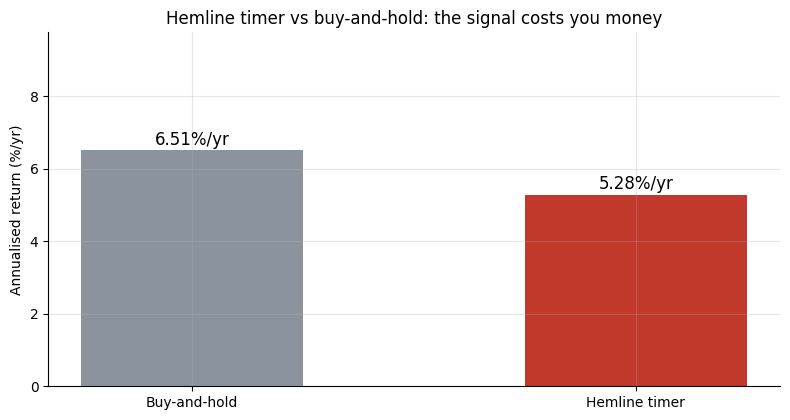

Buy-and-hold:    6.51%/yr
Hemline timer:   5.28%/yr
Advantage:       -1.23%/yr
Held 5 decades in market, 5 in cash

The timer went to cash in 1940s (+57%), 1970s (+20%), 2010s (+156%) -- all misses.


In [4]:
bt = st.timing_backtest(df_real)
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Buy-and-hold', 'Hemline timer'], [bt['bah_ann_pct'], bt['strat_ann_pct']],
       color=[GREY, RED], width=0.5)
ax.set_ylabel('Annualised return (%/yr)')
ax.set_title('Hemline timer vs buy-and-hold: the signal costs you money')
ax.set_ylim(0, max(bt['bah_ann_pct'], bt['strat_ann_pct']) * 1.5)
for rect, val in zip(ax.patches, [bt['bah_ann_pct'], bt['strat_ann_pct']]):
    ax.text(rect.get_x()+rect.get_width()/2, val + 0.05,
            f'{val:.2f}%/yr', ha='center', va='bottom', fontsize=12)
plt.tight_layout(); plt.show()
print(f'Buy-and-hold:    {bt["bah_ann_pct"]:.2f}%/yr')
print(f'Hemline timer:   {bt["strat_ann_pct"]:.2f}%/yr')
print(f'Advantage:       {bt["ann_advantage_pct"]:+.2f}%/yr')
print(f'Held {bt["n_held"]} decades in market, {bt["n_cash"]} in cash')
print('\nThe timer went to cash in 1940s (+57%), 1970s (+20%), 2010s (+156%) -- all misses.')

The hemline timer earns **+5.28%/yr** versus buy-and-hold's **+6.51%/yr** -- a **-1.23%/yr** penalty for following the fashion pages.  Beyond the return loss, the practical problem is fundamental: fashion cycles are retrospective.  You only know that the 1960s were 'the miniskirt decade' looking back from 1970.  Any live hemline signal would require real-time fashion forecasting -- itself an unsolved problem.

## 7 . Going further

- **The companion quant notebook** shows the Fisher's exact test derivation, the phi coefficient, the chi-square comparison (and why chi-square is unreliable at n = 10), the positive control confirming the engine would detect a real hemline signal if one existed, and a sensitivity analysis on the subjective proxy encoding: **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
- **Other spurious folk indicators on this desk:** [Study 158 -- Super-Bowl](../../158-super-bowl-indicator/) (same tiny-n structure); [Study 164 -- Mercury-Retrograde](../../164-mercury-retrograde/) (the canonical None/Mirage).
- **The year-ending-five study** (Study 161) is the closest comparable -- also a post-hoc pattern in a small sample, but one where the statistics at least clear the formal bar (Fisher-equivalent p < 0.05), unlike hemlines.
- **Want to challenge this?** The hemline encoding is inherently subjective.  Fork the study and try alternative encodings (e.g., the 1970s as 'mixed', the 1940s as 'rising' due to wartime practicality).  The desk prediction: hit rates will move by one or two decades and Fisher p will remain well above 0.05.

*The hemline indicator is market folklore at its most charming and its most misleading: a story so vivid it feels true, resting on n = 10 data points and a signal that is measurably worse than flipping a coin.*